# Installation


In [9]:
!pip install tnreason==2.0.0

# Random Walk

In [10]:
import numpy as np
from matplotlib import pyplot as plt

from tnreason import  engine

def get_marginal_matrix(cores, margVariables, dim):
    margs = np.empty((len(margVariables), dim))
    for i, margVar in enumerate(margVariables):
        rawMarginals = engine.contract(cores, openColors=[margVar]).values

        margs[i] = 1/np.sum(rawMarginals) * rawMarginals

    plt.imshow(margs, cmap="Reds", vmin=0, vmax=1)
    plt.title("Marginal distribution at each timestep")
    plt.ylabel("Time")
    plt.xlabel("States")
    return margs

In [11]:
def add_doVariable(doColor, headColor, doDim, sliceIterator):
    """
    Adds the do Variable to the sliceIterator describing a conditional distribution
    """
    return [(val, {**pos, doColor: doDim}) for (val, pos) in sliceIterator] + [(1, {headColor: i, doColor : i }) for i in range(doDim)]

In [12]:
def get_transitionIterator(t, dim=3, left_p=0.25, right_p=0.25, stay_p=0.5):
    return [(stay_p, {f"X_{t}": i, f"X_{t - 1}": i}) for i in range(dim)] + [
        (left_p, {f"X_{t}": dim - 1, f"X_{t - 1}": 0})] + [(left_p, {f"X_{t}": i - 1, f"X_{t - 1}": i}) for i in
                                                           range(1, dim)] + [
        (right_p, {f"X_{t}": 0, f"X_{t - 1}": dim - 1})] + [(left_p, {f"X_{t}": i + 1, f"X_{t - 1}": i}) for i in
                                                            range(dim - 1)]


def get_transitionCore(t, dim, left_p=0.25, right_p=0.25, stay_p=0.5, withIntervention=False):
    if withIntervention:
        return engine.create_from_slice_iterator(shape=[dim, dim, dim + 1],
                                                 colors=[f"X_{t}", f"X_{t - 1}", f"D_{t}"],
                                                 sliceIterator=add_doVariable(f"D_{t}", f"X_{t}", dim,
                                                                                 get_transitionIterator(t, dim, left_p,
                                                                                                        right_p,
                                                                                                        stay_p)))
    else:
        return engine.create_from_slice_iterator(
            shape=[dim, dim],
            colors=[f"X_{t}", f"X_{t - 1}"],
            sliceIterator=get_transitionIterator(t, dim, left_p, right_p, stay_p)
        )


def get_startCore(t, startPos, dim, varSuf="X_"):
    return engine.create_from_slice_iterator(
        shape=[dim],
        colors=[varSuf + f"{t}"],
        sliceIterator=[(1, {f"X_{t}": startPos})],
    )


def get_randomWalkCores(T, dim, left_p=0.25, right_p=0.25, stay_p=0.5, withIntervention=False):
    return {**{f"transition_{t}": get_transitionCore(t, dim, left_p, right_p, stay_p, withIntervention=withIntervention) for t in
               range(1, T)}, f"start": get_startCore(0, 0, dim)}


def get_responseCore(t, varSuf="X_", dim=3, withDo=False):
    if withDo:
        return engine.create_from_slice_iterator(
        colors=[varSuf + f"{t}", varSuf + f"{t - 1}", f"L_{t}", f"D_{t}"],
        shape=[dim, dim, 3, dim+1],
        sliceIterator=add_doVariable(f"D_{t}", varSuf+f"{t}", doDim = dim, sliceIterator=[(1, {varSuf + f"{t}": i - 1, varSuf + f"{t - 1}": i, f"L_{t}": 0}) for i in range(1, dim)] + [
            (1, {varSuf + f"{t}": dim - 1, varSuf + f"{t - 1}": 0, f"L_{t}": 0})] + [
                          (1, {varSuf + f"{t}": i, varSuf + f"{t - 1}": i, f"L_{t}": 1}) for i in range(dim)] + [
                          (1, {varSuf + f"{t}": i + 1, varSuf + f"{t - 1}": i, f"L_{t}": 2}) for i in
                          range(dim - 1)] + [(1, {varSuf + f"{t}": 0, varSuf + f"{t - 1}": dim - 1, f"L_{t}": 2})]
        ))
    else:
      return engine.create_from_slice_iterator(
        colors=[varSuf + f"{t}", varSuf + f"{t - 1}", f"L_{t}"],
        shape=[dim, dim, 3],
        sliceIterator=[(1, {varSuf + f"{t}": i - 1, varSuf + f"{t - 1}": i, f"L_{t}": 0}) for i in range(1, dim)] + [
            (1, {varSuf + f"{t}": dim - 1, varSuf + f"{t - 1}": 0, f"L_{t}": 0})] + [
                          (1, {varSuf + f"{t}": i, varSuf + f"{t - 1}": i, f"L_{t}": 1}) for i in range(dim)] + [
                          (1, {varSuf + f"{t}": i + 1, varSuf + f"{t - 1}": i, f"L_{t}": 2}) for i in
                          range(dim - 1)] + [(1, {varSuf + f"{t}": 0, varSuf + f"{t - 1}": dim - 1, f"L_{t}": 2})]
    )


def get_twinned_network(T, dim):
    return {**{f"resReal_{t}": get_responseCore(t, varSuf="X_", dim=dim) for t in range(1, T)},
            **{f"resCount_{t}": get_responseCore(t, varSuf="TX_", dim=dim, withDo=True) for t in range(1, T)},
            f"start": get_startCore(0, 0, dim)}

# Association and Intervention

In [13]:
def get_interventionCores(interventionDict, dim):
    return {"int_" + color: engine.create_from_slice_iterator(
        colors=[color],
        shape=[dim+1],
        sliceIterator=[(1, {color: interventionDict[color]})]
    ) for color in interventionDict}

array([[1.     , 0.     , 0.     , 0.     ],
       [0.5    , 0.25   , 0.     , 0.25   ],
       [0.375  , 0.25   , 0.125  , 0.25   ],
       [0.3125 , 0.25   , 0.1875 , 0.25   ],
       [0.28125, 0.25   , 0.21875, 0.25   ]])

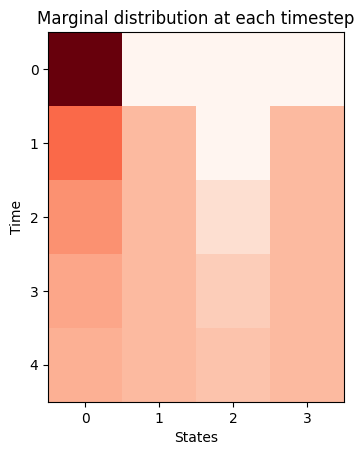

In [14]:
T = 5
dim = 4

cores = get_randomWalkCores(T=T, dim=dim, withIntervention=False)

get_marginal_matrix(get_randomWalkCores(T=T, dim=dim, withIntervention=False), [f"X_{i}" for i in range(T)],
                             dim=dim)

We investigate the effect of conditioning:

array([[1.   , 0.   , 0.   , 0.   ],
       [0.5  , 0.375, 0.   , 0.125],
       [0.375, 0.5  , 0.125, 0.   ],
       [0.   , 1.   , 0.   , 0.   ],
       [0.25 , 0.5  , 0.25 , 0.   ],
       [0.25 , 0.375, 0.25 , 0.125]])

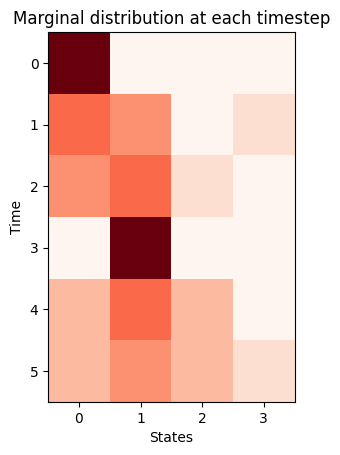

In [15]:
T = 6
dim = 4

conditionedVar = 3
conditionedState = 1

get_marginal_matrix({**get_randomWalkCores(T=T, dim=dim, withIntervention=False),
    "condCore": engine.create_from_slice_iterator(
        colors=[f"X_{conditionedVar}"],
        shape=[dim],
        sliceIterator=[(1, {f"X_{conditionedVar}": conditionedState})])
}, [f"X_{i}" for i in range(T)],
    dim=dim)

The effect is both on future and past.

Now we investigate the effect of intervening instead of conditioning:

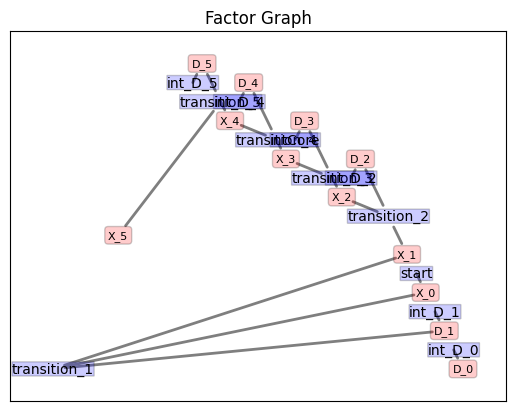

In [17]:
intervenedVar=3
intervenedState = 1

engine.draw_factor_graph({**get_randomWalkCores(T=T, dim=dim, withIntervention=True),
                           **get_interventionCores({f"D_{t}": dim for t in range(T) if t!=intervenedVar}, dim),
    "intCore": engine.create_from_slice_iterator(
        colors=[f"D_{intervenedVar}"],
        shape=[dim + 1],
        sliceIterator=[(1, {f"D_{intervenedVar}": intervenedState})]
    )
})

array([[1.   , 0.   , 0.   , 0.   ],
       [0.5  , 0.25 , 0.   , 0.25 ],
       [0.375, 0.25 , 0.125, 0.25 ],
       [0.   , 1.   , 0.   , 0.   ],
       [0.25 , 0.5  , 0.25 , 0.   ],
       [0.25 , 0.375, 0.25 , 0.125]])

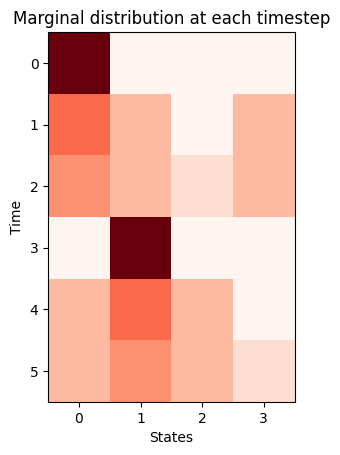

In [18]:
T = 6
dim = 4

intervenedVar = 3
intervenedState = 1

get_marginal_matrix({**get_randomWalkCores(T=T, dim=dim, withIntervention=True),
                           **get_interventionCores({f"D_{t}": dim for t in range(T) if t!=intervenedVar}, dim),
    "intCore": engine.create_from_slice_iterator(
        colors=[f"D_{intervenedVar}"],
        shape=[dim + 1],
        sliceIterator=[(1, {f"D_{intervenedVar}": intervenedState})]
    )
}, [f"X_{i}" for i in range(T)], dim=dim)

The effect is only on the future.

# Counterfactuals

We now investigate the influence of intervening in a counterfactual world.

In [19]:
def get_observationCores(observationDict, dim):
    return {"obs_" + color: engine.create_from_slice_iterator(
        colors=[color],
        shape=[dim],
        sliceIterator=[(1, {color: observationDict[color]})]
    ) for color in observationDict}

array([[0., 1., 0., 0.],
       [0., 1., 0., 0.]])

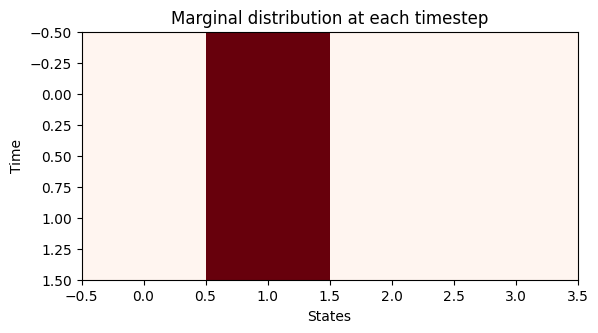

In [21]:
T = 3
dim = 4
interventedVar = 1
interventedState = 1

get_marginal_matrix({**get_twinned_network(T=T, dim=dim),
                     **get_observationCores({f"X_{t}": 0 for t in range(1, T)}, dim),
                     **get_interventionCores({f"D_{t}": dim for t in range(T) if t!=interventedVar}, dim),
                     "intCore": engine.create_from_slice_iterator(
                      colors=[f"D_{interventedVar}"],
                      shape=[dim + 1],
                      sliceIterator=[(1, {f"D_{interventedVar}": interventedState})]
    )
                     },
                       [f"TX_{i}" for i in range(1, T)], dim)

We get a deterministic walk, shifted by the intervention, in the counterfactual world.